In [3]:
import keras
from keras.applications.resnet50 import ResNet50
from keras.applications.resnet50 import preprocess_input, decode_predictions
import numpy as np


model = ResNet50(weights='imagenet')


img_path = '/cat.jpg'
img = keras.utils.load_img(img_path, target_size=(224, 224))
x = keras.utils.img_to_array(img)
x = np.expand_dims(x, axis=0)
x = preprocess_input(x)


preds = model.predict(x)
# decode the results into a list of tuples (class, description, probability)
# (one such list for each sample in the batch)
print('Predicted:', decode_predictions(preds, top=5)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Predicted: [('n02123045', 'tabby', np.float32(0.7382206)), ('n02123159', 'tiger_cat', np.float32(0.199971)), ('n02127052', 'lynx', np.float32(0.04411878)), ('n02124075', 'Egyptian_cat', np.float32(0.006825985)), ('n03958227', 'plastic_bag', np.float32(0.0020755494))]


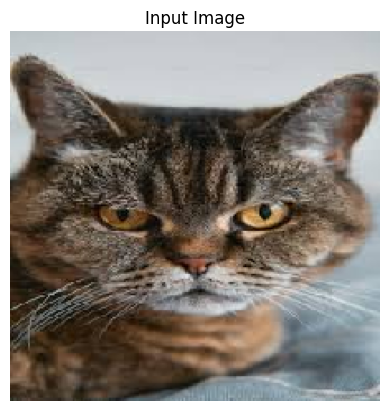

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

Top Predictions:
1. tabby - 73.82%
2. tiger_cat - 20.00%
3. lynx - 4.41%


In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions


# Load pretrained ResNet50 model
model = ResNet50(weights="imagenet")


def predict_image(img_path, top_k=3):
    """
    Predict the class of an image using pretrained ResNet50.
    """

    if not os.path.exists(img_path):
        print("Image not found:", img_path)
        return

    # Load image
    img = keras.utils.load_img(img_path, target_size=(224, 224))

    # Display image
    plt.imshow(img)
    plt.axis("off")
    plt.title("Input Image")
    plt.show()

    # Convert image to array
    x = keras.utils.img_to_array(img)

    # Add batch dimension: (224,224,3) -> (1,224,224,3)
    x = np.expand_dims(x, axis=0)

    # Preprocess for ResNet50
    x = preprocess_input(x)

    # Predict
    preds = model.predict(x)

    # Decode predictions
    results = decode_predictions(preds, top=top_k)[0]

    print("\nTop Predictions:")
    for i, (class_id, class_name, probability) in enumerate(results, start=1):
        print(f"{i}. {class_name} - {probability*100:.2f}%")


# Example usage
img_path = "/cat.jpg"
predict_image(img_path, top_k=3)

Saving cow.jpg to cow.jpg
Uploaded file: cow.jpg


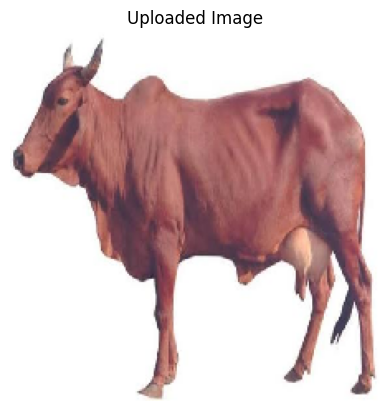

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Top Predictions:
1. ox - 42.03%
2. hartebeest - 40.51%
3. oxcart - 14.06%
4. sorrel - 1.58%
5. ibex - 0.46%
6. water_buffalo - 0.20%
7. gazelle - 0.18%
8. impala - 0.09%
9. plow - 0.08%
10. bighorn - 0.06%


In [6]:
from google.colab import files
import os
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.applications.resnet50 import ResNet50, preprocess_input, decode_predictions

model = ResNet50(weights="imagenet")

def predict_image(img_path, top_k=3):
    img = keras.utils.load_img(img_path, target_size=(224, 224))

    plt.imshow(img)
    plt.axis("off")
    plt.title("Uploaded Image")
    plt.show()

    x = keras.utils.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    preds = model.predict(x)
    results = decode_predictions(preds, top=top_k)[0]

    print("Top Predictions:")
    for i, (class_id, class_name, probability) in enumerate(results, start=1):
        print(f"{i}. {class_name} - {probability*100:.2f}%")


uploaded = files.upload()

for filename in uploaded.keys():
    print("Uploaded file:", filename)
    predict_image(filename, top_k=10)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.applications.resnet50 import ResNet50
from keras.applications.resnet50 import preprocess_input, decode_predictions
from google.colab import files

# Load pretrained model
model = ResNet50(weights='imagenet')

# Upload image
uploaded = files.upload()

for filename in uploaded.keys():

    # Load image
    img = keras.utils.load_img(filename, target_size=(224,224))

    # Show image
    plt.imshow(img)
    plt.axis("off")
    plt.title("Uploaded Fruit Image")
    plt.show()

    # Convert image to array
    x = keras.utils.img_to_array(img)

    # Add batch dimension
    x = np.expand_dims(x, axis=0)

    # Preprocess image
    x = preprocess_input(x)

    # Predict
    preds = model.predict(x)

    # Decode predictions
    results = decode_predictions(preds, top=3)[0]

    print("\nTop Predictions:")
    for i, (class_id, class_name, probability) in enumerate(results, start=1):
        print(f"{i}. {class_name} --> {probability*100:.2f}%")

14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Saving cr.jpg to cr.jpg


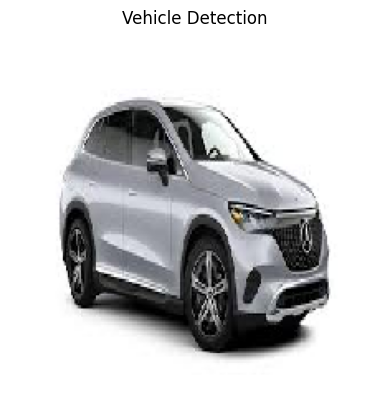

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Predictions:
1. minivan --> 85.48%
2. minibus --> 3.28%
3. beach_wagon --> 3.11%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.applications.mobilenet_v2 import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input, decode_predictions
from google.colab import files

# Load pretrained model
model = MobileNetV2(weights='imagenet')

# Upload image
uploaded = files.upload()

for filename in uploaded.keys():

    img = keras.utils.load_img(filename, target_size=(224,224))

    plt.imshow(img)
    plt.axis("off")
    plt.title("Vehicle Detection")
    plt.show()

    x = keras.utils.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    preds = model.predict(x)

    results = decode_predictions(preds, top=3)[0]

    print("\nPredictions:")
    for i, (class_id, class_name, probability) in enumerate(results, start=1):
        print(f"{i}. {class_name} --> {probability*100:.2f}%")


Saving download.jpg to download (1).jpg


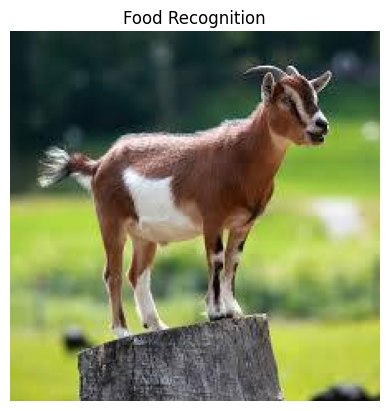

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step

Food Predictions:
1. ibex --> 69.29%
2. gazelle --> 10.10%
3. bighorn --> 4.87%


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras.applications.efficientnet import EfficientNetB0
from keras.applications.efficientnet import preprocess_input, decode_predictions
from google.colab import files

# Load pretrained model
model = EfficientNetB0(weights='imagenet')

# Upload image
uploaded = files.upload()

for filename in uploaded.keys():

    img = keras.utils.load_img(filename, target_size=(224,224))

    plt.imshow(img)
    plt.axis("off")
    plt.title("Food Recognition")
    plt.show()

    x = keras.utils.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)

    preds = model.predict(x)

    results = decode_predictions(preds, top=3)[0]

    print("\nFood Predictions:")
    for i, (class_id, class_name, probability) in enumerate(results, start=1):
        print(f"{i}. {class_name} --> {probability*100:.2f}%")